# Titanic Dataset Classification

สร้าง classification model เพื่อทำนายว่าผู้โดยสารจะรอดชีวิตจากเหตุการณ์เรือไททานิกอับปาง

## Section 01: Import Libraries

In [1]:
import pickle   
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn import tree
from sklearn.tree import _tree

## Section 02: Load and Explore Data

In [2]:
# Load dataset
df = pd.read_csv('/Users/pasunimsuwan/Desktop/DPU/DT-514/W5/titanic.csv')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,20.0,0,0,4.0125,C
1,0,3,male,34.5,0,0,6.4375,C
2,0,3,male,20.0,0,0,7.2250,C
3,0,3,male,21.0,0,0,7.2250,C
4,0,3,male,22.5,0,0,7.2250,C


In [3]:
# Check data info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1043 entries, 0 to 1042
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  1043 non-null   int64  
 1   pclass    1043 non-null   int64  
 2   sex       1043 non-null   str    
 3   age       1043 non-null   float64
 4   sibsp     1043 non-null   int64  
 5   parch     1043 non-null   int64  
 6   fare      1043 non-null   float64
 7   embarked  1043 non-null   str    
dtypes: float64(2), int64(4), str(2)
memory usage: 65.3 KB


In [4]:
# Check for missing values
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

## Section 03: Preprocess Data

In [5]:
# Assign data types
df['survived'] = df['survived'].astype('category')
df['pclass'] = df['pclass'].astype('category')
df['sex'] = df['sex'].astype('category')
df['age'] = df['age'].astype('Float64')
df['sibsp'] = df['sibsp'].astype('Int64')
df['parch'] = df['parch'].astype('Int64')
df['fare'] = df['fare'].astype('Float64')
df['embarked'] = df['embarked'].astype('category')
df.dtypes

survived    category
pclass      category
sex         category
age          Float64
sibsp          Int64
parch          Int64
fare         Float64
embarked    category
dtype: object

In [6]:
# Perform one-hot encoding
df = pd.get_dummies(df, dtype=int, columns=['pclass', 'sex', 'embarked'])
df.head()

,survived,age,sibsp,parch,fare,pclass_1,pclass_2,pclass_3,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,0,20.0,0,0,4.0125,0,0,1,0,1,1,0,0
1,0,34.5,0,0,6.4375,0,0,1,0,1,1,0,0
2,0,20.0,0,0,7.225,0,0,1,0,1,1,0,0
3,0,21.0,0,0,7.225,0,0,1,0,1,1,0,0
4,0,22.5,0,0,7.225,0,0,1,0,1,1,0,0


In [7]:
# Perform min-max normalization
scaler = MinMaxScaler()
df['age'] = scaler.fit_transform(df[['age']])
df['sibsp'] = scaler.fit_transform(df[['sibsp']])
df['parch'] = scaler.fit_transform(df[['parch']])
df['fare'] = scaler.fit_transform(df[['fare']])
df.head()

,survived,age,sibsp,parch,fare,pclass_1,pclass_2,pclass_3,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,0,0.248434,0.0,0.0,0.007832,0,0,1,0,1,1,0,0
1,0,0.430062,0.0,0.0,0.012565,0,0,1,0,1,1,0,0
2,0,0.248434,0.0,0.0,0.014102,0,0,1,0,1,1,0,0
3,0,0.260960,0.0,0.0,0.014102,0,0,1,0,1,1,0,0
4,0,0.279749,0.0,0.0,0.014102,0,0,1,0,1,1,0,0


In [8]:
# Split features and target
X = df.drop(['survived'], axis=1)
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=45)
print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')

Training set: 698 samples
Test set: 345 samples


## Section 04: Cross Validation

In [9]:
# Initial parameters
max_depth = 3
criterion = 'entropy'

# Test parameters
clf = tree.DecisionTreeClassifier(criterion=criterion, max_depth=max_depth)
scoring = ['accuracy', 'precision', 'recall', 'f1_macro']
scores = cross_validate(clf, X_train, y_train, cv=5, scoring=scoring)
print('fit_time       :', scores['fit_time'].mean())
print('score_time     :', scores['score_time'].mean())
print('test_accuracy  :', scores['test_accuracy'].mean())
print('test_precision :', scores['test_precision'].mean())
print('test_recall    :', scores['test_recall'].mean())
print('test_f1_macro  :', scores['test_f1_macro'].mean())

fit_time       : 0.003310680389404297
score_time     : 0.02094259262084961
test_accuracy  : 0.7980164439876669
test_precision : 0.7809543842682141
test_recall    : 0.667878787878788
test_f1_macro  : 0.7786555829839172


Text(0.5, 1.0, 'Gini Criterion - Performance vs Max Depth')

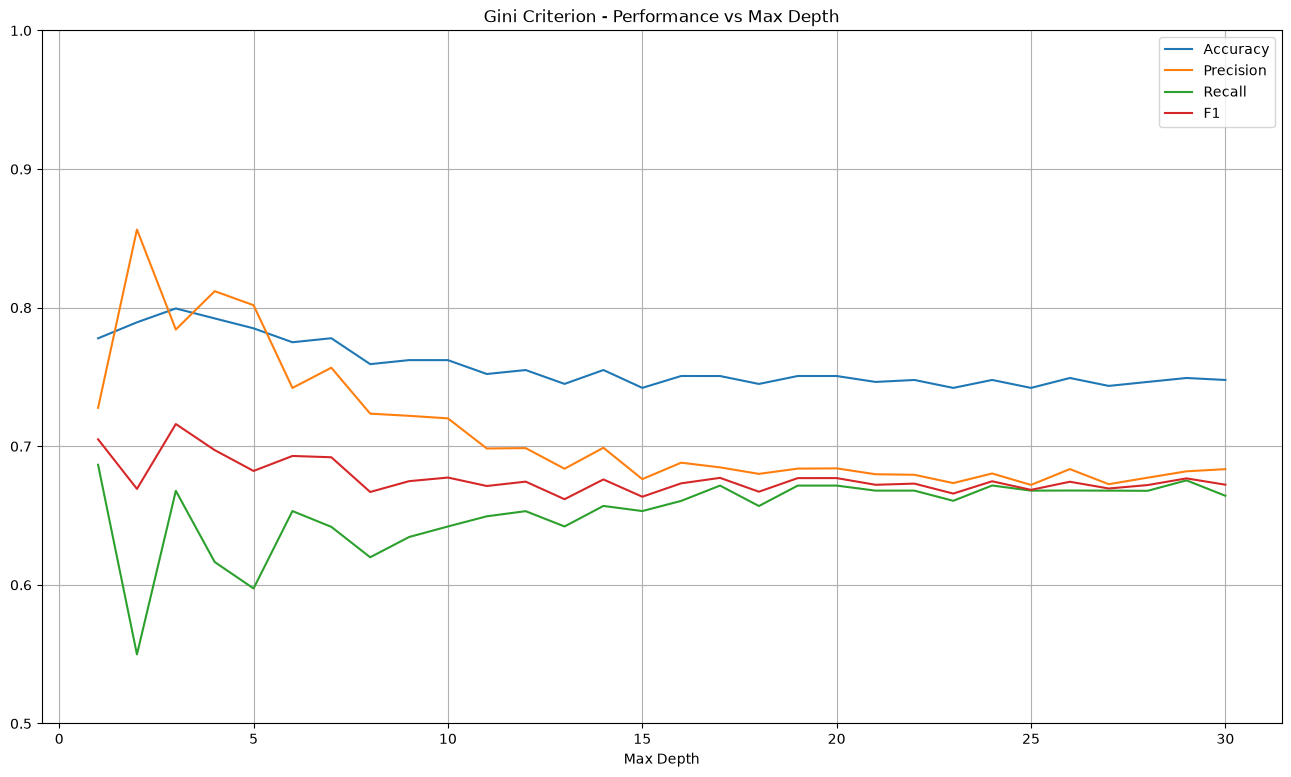

In [10]:
# Observe max_depth with Gini criterion
max_depth_values = []
accuracy = []
precision = []
recall = []
f1 = []

criterion = 'gini'

for i in range(1, 31):
    clf = tree.DecisionTreeClassifier(criterion=criterion, max_depth=i)
    scoring = ['accuracy', 'precision', 'recall', 'f1']
    scores = cross_validate(clf, X_train, y_train, cv=5, scoring=scoring)

    max_depth_values.append(i)
    accuracy.append(scores['test_accuracy'].sum() / 5)
    precision.append(scores['test_precision'].sum() / 5)
    recall.append(scores['test_recall'].sum() / 5)
    f1.append(scores['test_f1'].sum() / 5)

fig, ax = plt.subplots(figsize=(16, 9))
ax.plot(max_depth_values, accuracy, label='Accuracy')    
ax.plot(max_depth_values, precision, label='Precision')
ax.plot(max_depth_values, recall, label='Recall')
ax.plot(max_depth_values, f1, label='F1')

ax.legend()
ax.set_ylim([0.5, 1])
ax.grid()
ax.set_xlabel('Max Depth')
ax.set_title('Gini Criterion - Performance vs Max Depth')

Text(0.5, 1.0, 'Entropy Criterion - Performance vs Max Depth')

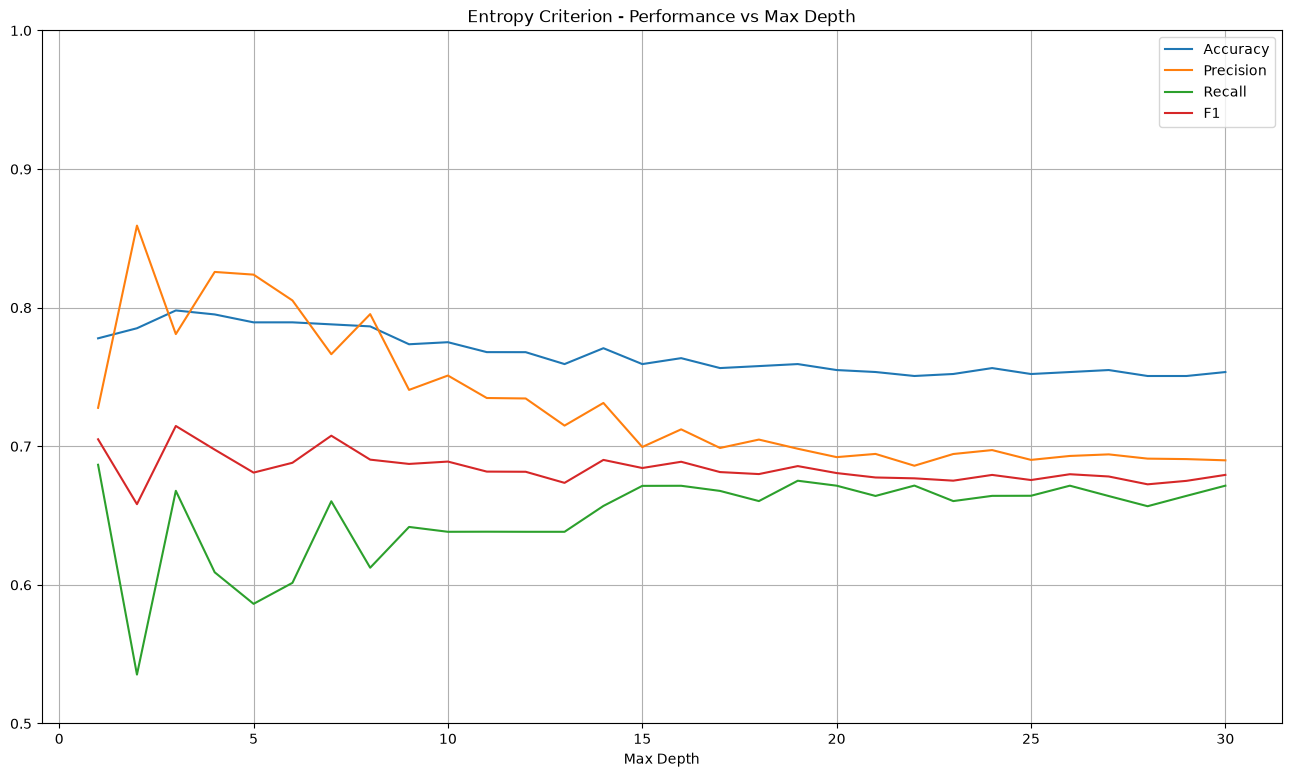

In [11]:
# Observe max_depth with Entropy criterion
accuracy_ent = []
precision_ent = []
recall_ent = []
f1_ent = []

criterion = 'entropy'

for i in range(1, 31):
    clf = tree.DecisionTreeClassifier(criterion=criterion, max_depth=i)
    scoring = ['accuracy', 'precision', 'recall', 'f1']
    scores = cross_validate(clf, X_train, y_train, cv=5, scoring=scoring)

    accuracy_ent.append(scores['test_accuracy'].sum() / 5)
    precision_ent.append(scores['test_precision'].sum() / 5)
    recall_ent.append(scores['test_recall'].sum() / 5)
    f1_ent.append(scores['test_f1'].sum() / 5)

fig, ax = plt.subplots(figsize=(16, 9))
ax.plot(max_depth_values, accuracy_ent, label='Accuracy')    
ax.plot(max_depth_values, precision_ent, label='Precision')
ax.plot(max_depth_values, recall_ent, label='Recall')
ax.plot(max_depth_values, f1_ent, label='F1')

ax.legend()
ax.set_ylim([0.5, 1])
ax.grid()
ax.set_xlabel('Max Depth')
ax.set_title('Entropy Criterion - Performance vs Max Depth')

## Section 05: Build Classification Model

              precision    recall  f1-score   support

        Died       0.79      0.87      0.83       191
    Survived       0.82      0.71      0.76       154

    accuracy                           0.80       345
   macro avg       0.80      0.79      0.79       345
weighted avg       0.80      0.80      0.80       345



Text(0.5, 1.0, 'Confusion Matrix')

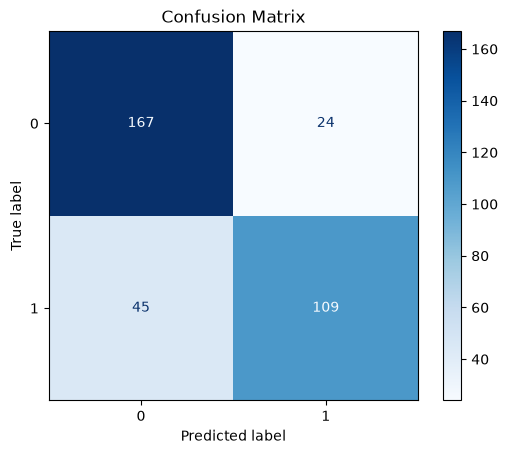

In [12]:
# Train model with best parameters
clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=4)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
target_names = ['Died', 'Survived']
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')

In [13]:
# Save model
clf_full = tree.DecisionTreeClassifier(criterion='entropy', max_depth=4)
clf_full.fit(X, y)
filename = "model_02.mod"
pickle.dump(clf_full, open(filename, 'wb'))
print(f'Model saved to {filename}')

Model saved to model_02.mod


## Section 06: Extract Knowledge from Model

Text(0.5, 1.0, 'Titanic Decision Tree')

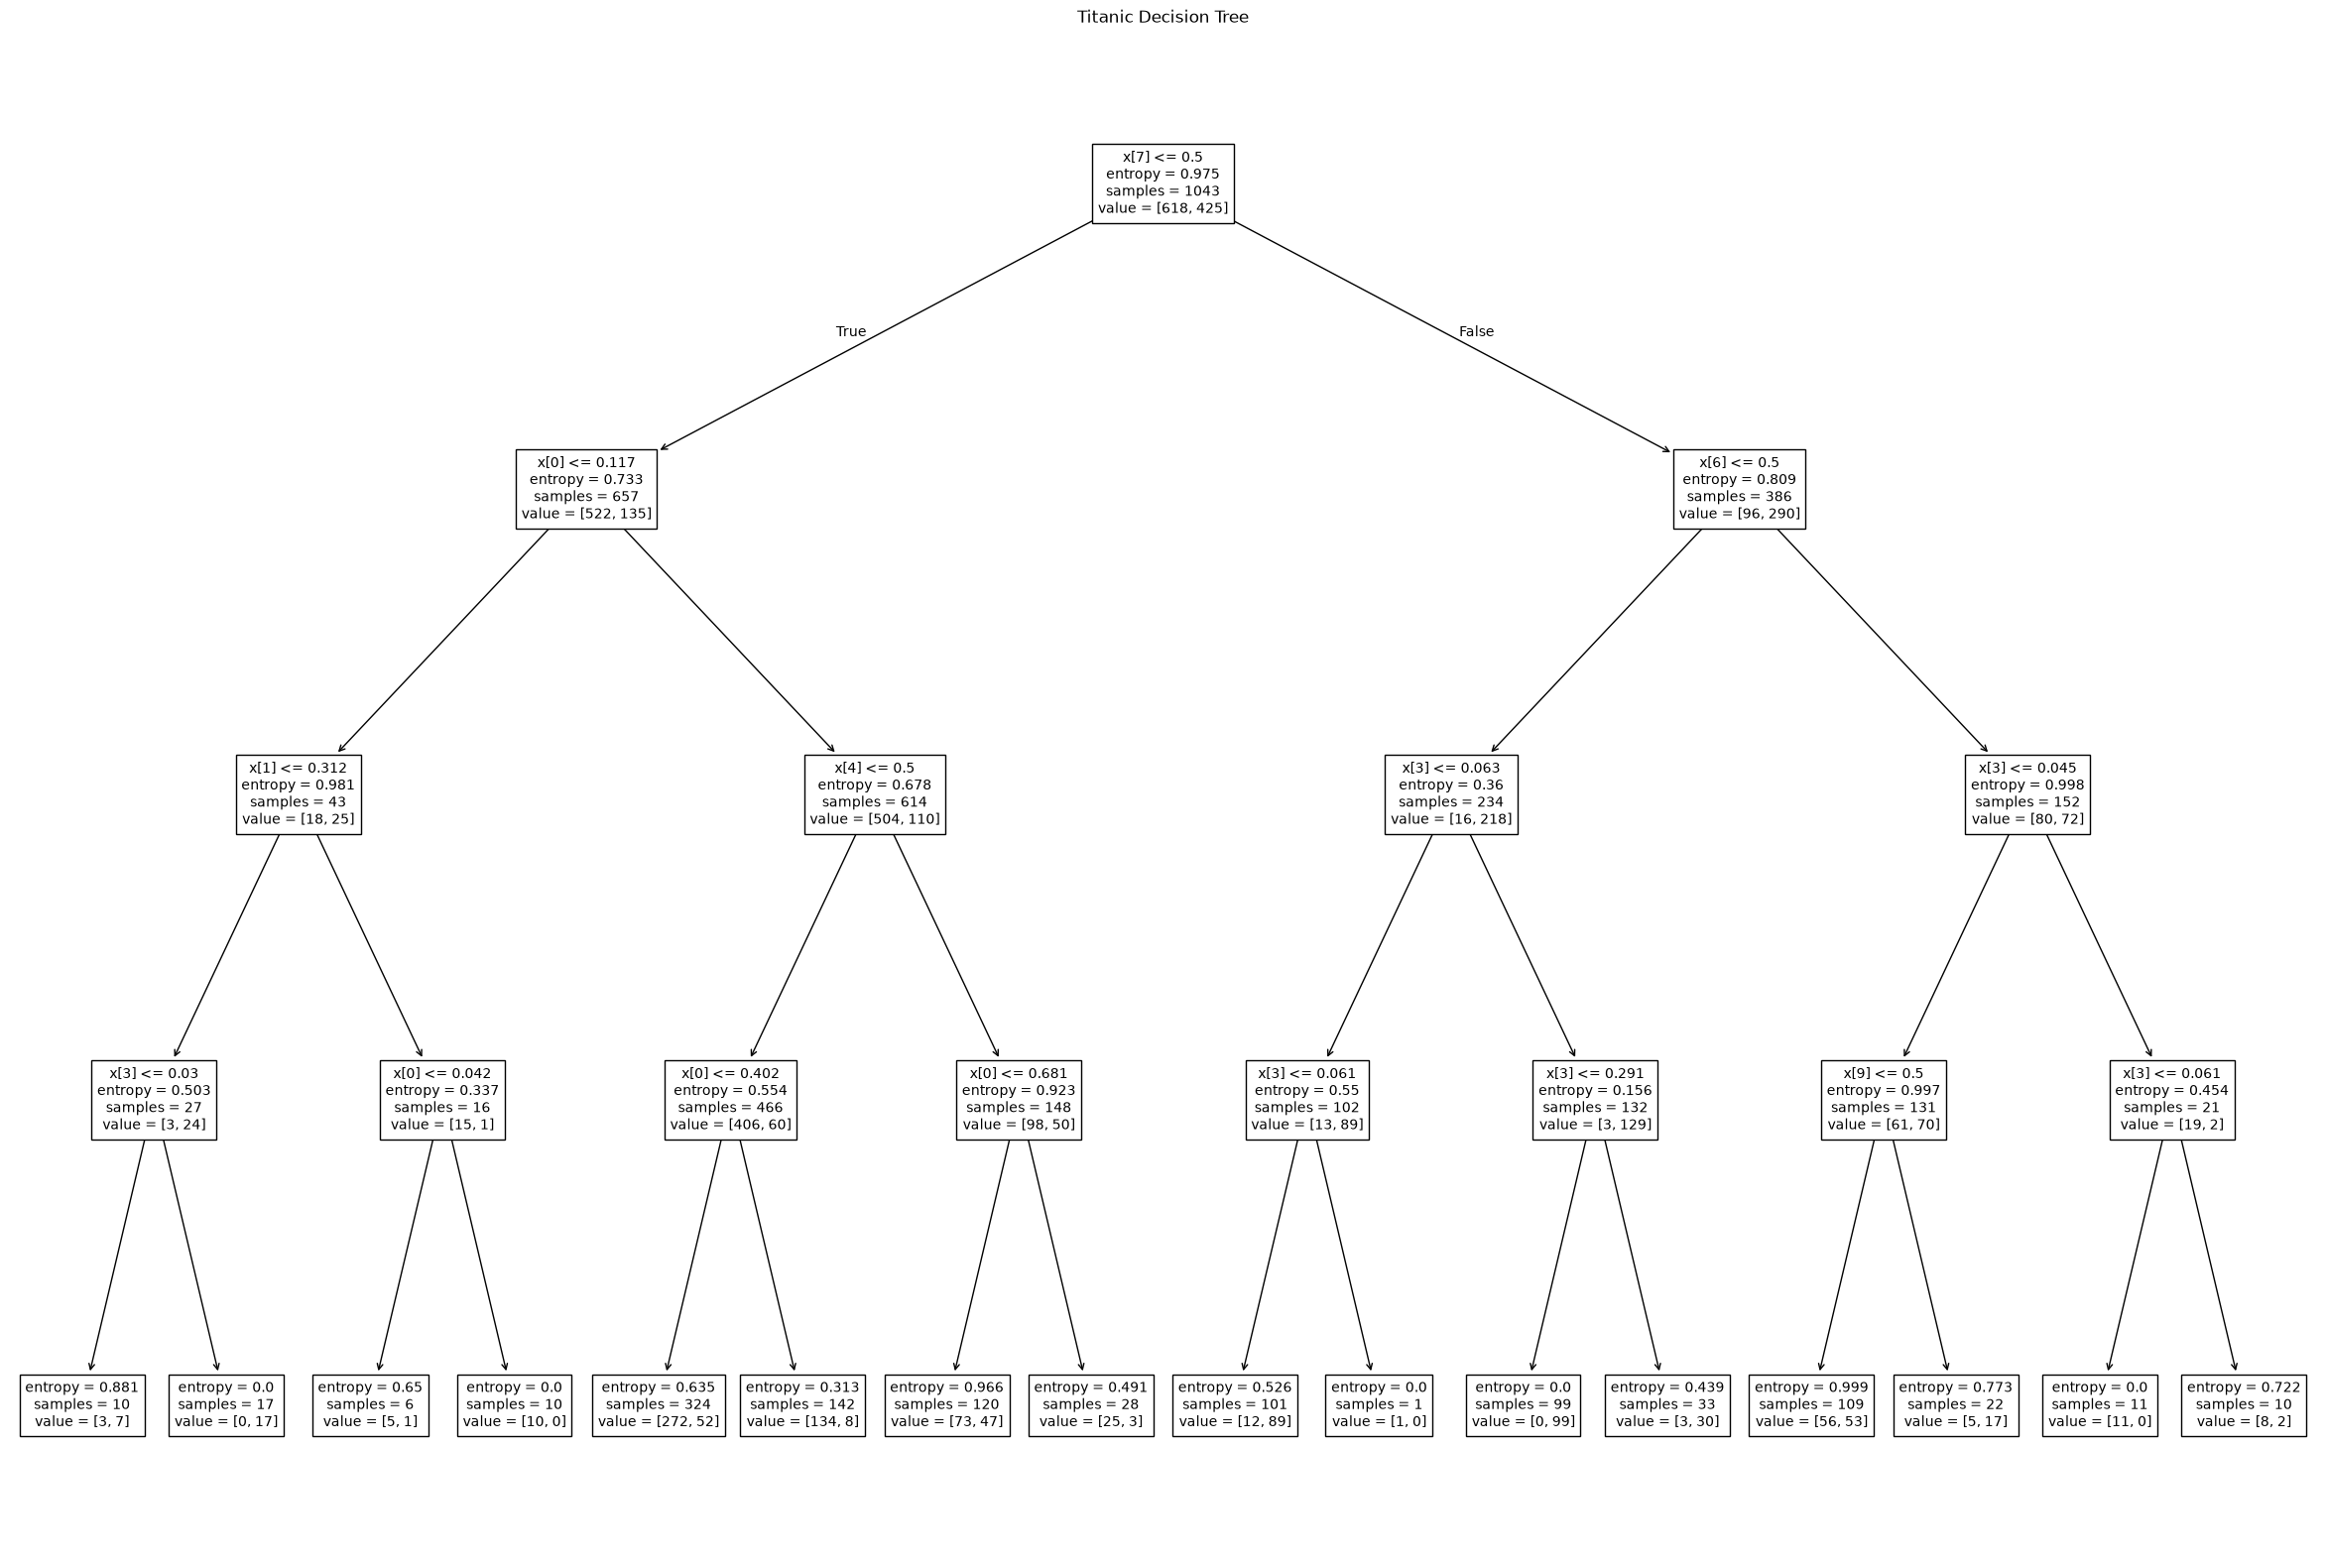

In [14]:
# Visualize decision tree
fig, ax = plt.subplots(figsize=(30, 20))
tree.plot_tree(clf_full, ax=ax);
plt.title('Titanic Decision Tree')

In [15]:
# Text representation
text_tree = tree.export_text(clf_full)
print(text_tree)

|--- feature_7 <= 0.50
|   |--- feature_0 <= 0.12
|   |   |--- feature_1 <= 0.31
|   |   |   |--- feature_3 <= 0.03
|   |   |   |   |--- class: 1
|   |   |   |--- feature_3 >  0.03
|   |   |   |   |--- class: 1
|   |   |--- feature_1 >  0.31
|   |   |   |--- feature_0 <= 0.04
|   |   |   |   |--- class: 0
|   |   |   |--- feature_0 >  0.04
|   |   |   |   |--- class: 0
|   |--- feature_0 >  0.12
|   |   |--- feature_4 <= 0.50
|   |   |   |--- feature_0 <= 0.40
|   |   |   |   |--- class: 0
|   |   |   |--- feature_0 >  0.40
|   |   |   |   |--- class: 0
|   |   |--- feature_4 >  0.50
|   |   |   |--- feature_0 <= 0.68
|   |   |   |   |--- class: 0
|   |   |   |--- feature_0 >  0.68
|   |   |   |   |--- class: 0
|--- feature_7 >  0.50
|   |--- feature_6 <= 0.50
|   |   |--- feature_3 <= 0.06
|   |   |   |--- feature_3 <= 0.06
|   |   |   |   |--- class: 1
|   |   |   |--- feature_3 >  0.06
|   |   |   |   |--- class: 0
|   |   |--- feature_3 >  0.06
|   |   |   |--- feature_3 <= 0.29
| 

In [16]:
# Extract human-readable rules
def get_rules(tree, feature_names, class_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    paths = []
    path = []
    
    def recurse(node, path, paths):
        
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            p1, p2 = list(path), list(path)
            p1 += [f"({name} <= {np.round(threshold, 3)})"]
            recurse(tree_.children_left[node], p1, paths)
            p2 += [f"({name} > {np.round(threshold, 3)})"]
            recurse(tree_.children_right[node], p2, paths)
        else:
            path += [(tree_.value[node], tree_.n_node_samples[node])]
            paths += [path]
            
    recurse(0, path, paths)

    # sort by samples count
    samples_count = [p[-1][1] for p in paths]
    ii = list(np.argsort(samples_count))
    paths = [paths[i] for i in reversed(ii)]
    
    rules = []
    for path in paths:
        rule = "if "
        
        for p in path[:-1]:
            if rule != "if ":
                rule += " and "
            rule += str(p)
        rule += " then "
        if class_names is None:
            rule += "response: "+str(np.round(path[-1][0][0][0],3))
        else:
            classes = path[-1][0][0]
            l = np.argmax(classes)
            rule += f"class: {class_names[l]} (proba: {np.round(100.0*classes[l]/np.sum(classes),2)}%)"
        rule += f" | based on {path[-1][1]:,} samples"
        rules += [rule]
        
    return rules

feature_names = ['pclass_1', 'pclass_2', 'pclass_3', 'sex_female', 'sex_male', 'age', 'sibsp', 'parch', 'fare', 'embarked_C', 'embarked_Q', 'embarked_S']
class_names = ['Died', 'Survived']
rules = get_rules(clf_full, feature_names, class_names)

print("=== Decision Rules ===")
for i, r in enumerate(rules, 1):
    print(f"{i}. {r}")

=== Decision Rules ===
1. if (parch <= 0.5) and (pclass_1 > 0.117) and (sex_male <= 0.5) and (pclass_1 <= 0.402) then class: Died (proba: 83.95%) | based on 324 samples
2. if (parch <= 0.5) and (pclass_1 > 0.117) and (sex_male <= 0.5) and (pclass_1 > 0.402) then class: Died (proba: 94.37%) | based on 142 samples
3. if (parch <= 0.5) and (pclass_1 > 0.117) and (sex_male > 0.5) and (pclass_1 <= 0.681) then class: Died (proba: 60.83%) | based on 120 samples
4. if (parch > 0.5) and (sibsp > 0.5) and (sex_female <= 0.045) and (embarked_C <= 0.5) then class: Died (proba: 51.38%) | based on 109 samples
5. if (parch > 0.5) and (sibsp <= 0.5) and (sex_female <= 0.063) and (sex_female <= 0.061) then class: Survived (proba: 88.12%) | based on 101 samples
6. if (parch > 0.5) and (sibsp <= 0.5) and (sex_female > 0.063) and (sex_female <= 0.291) then class: Survived (proba: 100.0%) | based on 99 samples
7. if (parch > 0.5) and (sibsp <= 0.5) and (sex_female > 0.063) and (sex_female > 0.291) then cla

## Section 07: Feature Engineering for Production

In [17]:
# Define feature engineering function
def feature_engineer(x_org):
    
    x_tmp = {}
    
    # Engineering 'age'
    age_org = x_org['age']
    x_tmp['age'] = (age_org - 0.1667) / (80.0000 - 0.1667)

    # Engineering 'sibsp'
    sibsp_org = x_org['sibsp']
    x_tmp['sibsp'] = (sibsp_org - 0) / (8 - 0)
    
    # Engineering 'parch'
    parch_org = x_org['parch']
    x_tmp['parch'] = (parch_org - 0) / (6 - 0)

    # Engineering 'fare'
    fare_org = x_org['fare']
    x_tmp['fare'] = (fare_org - 0) / (512.329200 - 0)

    # Engineering 'pclass'
    pclass_org = x_org['pclass']
    if pclass_org == 1:
        x_tmp['pclass_1'] = 1
        x_tmp['pclass_2'] = 0
        x_tmp['pclass_3'] = 0
    elif pclass_org == 2:
        x_tmp['pclass_1'] = 0
        x_tmp['pclass_2'] = 1
        x_tmp['pclass_3'] = 0
    elif pclass_org == 3:    
        x_tmp['pclass_1'] = 0
        x_tmp['pclass_2'] = 0
        x_tmp['pclass_3'] = 1
    else:
        x_tmp['pclass_1'] = 0
        x_tmp['pclass_2'] = 0
        x_tmp['pclass_3'] = 1
    
    # Engineering 'sex'
    sex_org = x_org['sex']
    if sex_org == 'male':
        x_tmp['sex_female'] = 0
        x_tmp['sex_male'] = 1
    elif sex_org == 'female':
        x_tmp['sex_female'] = 1
        x_tmp['sex_male'] = 0
    else:
        x_tmp['sex_female'] = 0
        x_tmp['sex_male'] = 1

    # Engineering 'embarked'
    embared_org = x_org['embarked']
    if embared_org == 'C':
        x_tmp['embarked_C'] = 1
        x_tmp['embarked_Q'] = 0
        x_tmp['embarked_S'] = 0
    elif embared_org == 'Q':
        x_tmp['embarked_C'] = 0
        x_tmp['embarked_Q'] = 1
        x_tmp['embarked_S'] = 0
    elif embared_org == 'S':
        x_tmp['embarked_C'] = 0
        x_tmp['embarked_Q'] = 0
        x_tmp['embarked_S'] = 1
    else:
        x_tmp['embarked_C'] = 0
        x_tmp['embarked_Q'] = 0
        x_tmp['embarked_S'] = 1

    return x_tmp

## Section 08: Prediction Module

In [18]:
# Load model for production
tree_mod = pickle.load(open("model_02.mod", 'rb'))

def model_predict(X_raw):
    # Feature engineering
    df_final = pd.DataFrame()
    for i in range(0, X_raw.shape[0]):
        x_org = X_raw.iloc[i, 1:]  # skip 'passengerid'
        x_prc = feature_engineer(x_org)
        df_tmp = pd.DataFrame([x_prc])
        df_final = pd.concat([df_final, df_tmp])
    
    # Predict
    y_pred = tree_mod.predict(df_final)
    return y_pred

# Test prediction
df_test = pd.read_csv('/Users/pasunimsuwan/Desktop/DPU/DT-514/W5/titanic.csv')
y_pred = model_predict(df_test)
print(f"Predictions: {y_pred[:20]}")
print(f"Total predictions: {len(y_pred)}")

Predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Total predictions: 1043
